<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/Kalyani_second_dataset_r2_score_0_69.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df=pd.read_excel('/content/drive/MyDrive/Dr Kalyani thesis training Dataset KH KV AL ACD LT.xlsx')

In [ ]:
X = df[['KH', 'KV','AGE ']]
y = df['AL']

In [ ]:
# prompt: Linear regression

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('R-squared:', metrics.r2_score(y_test, y_pred))

Mean Absolute Error: 0.4236558287916986
Mean Squared Error: 0.34247417503231103
Root Mean Squared Error: 0.5852129313611508
R-squared: 0.6566593450322427


In [ ]:
# prompt: Polynomials

import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# Create polynomial features (e.g., degree 2)
poly_features = PolynomialFeatures(degree=2)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

# Create and train the polynomial regression model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Make predictions on the test set
y_pred_poly = poly_model.predict(X_test_poly)

# Evaluate the polynomial model
print('\nPolynomial Regression Evaluation:')
print('Polynomial Coefficients:', poly_model.coef_)
print('Polynomial Intercept:', poly_model.intercept_)
print('Polynomial R-squared:', poly_model.score(X_test_poly, y_test))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred_poly))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, y_pred_poly)))
print('R2 Score:', r2_score(y_test, y_pred_poly))

# Optional: Plot the predictions vs actual values for one feature (if degree 2 and one feature)
# This is more complex for multiple features or higher degrees for a simple 2D plot.
if X.shape[1] == 1 and 2 == 2: # Check if original X had only one feature and degree is 2
    plt.scatter(X_test, y_test, color='blue', label='Actual')
    # To plot the polynomial fit, we need to sort the test data based on the feature
    sort_axis = np.argsort(X_test.iloc[:, 0])
    sorted_X_test = X_test.iloc[sort_axis]
    sorted_X_test_poly = poly_features.transform(sorted_X_test)
    sorted_y_pred_poly = poly_model.predict(sorted_X_test_poly)
    plt.plot(sorted_X_test, sorted_y_pred_poly, color='red', linewidth=2, label='Polynomial Fit')
    plt.xlabel(X.columns[0])
    plt.ylabel('AL')
    plt.title('Polynomial Regression (Degree 2)')
    plt.legend()
    plt.show()
elif X.shape[1] > 1:
    print("\nSkipping polynomial fit plot as there are multiple features.")



Polynomial Regression Evaluation:
Polynomial Coefficients: [ 0.00000000e+00  1.89471455e+00 -9.83103574e-01  4.62092139e-02
 -4.63716615e-02  3.20777038e-02  9.34508716e-03  2.72562218e-03
 -1.32194403e-02  1.16076919e-03]
Polynomial Intercept: 8.529209036903026
Polynomial R-squared: 0.6938777699734988
Mean Squared Error: 0.3053496772679677
Root Mean Squared Error: 0.5525845430954142
R2 Score: 0.6938777699734988

Skipping polynomial fit plot as there are multiple features.


In [ ]:
# prompt: Equation

coefficients = poly_model.coef_
intercept = poly_model.intercept_
feature_names = ['KH', 'KV', 'AGE '] # Original feature names

# Get the powers for each term from the fitted PolynomialFeatures
poly_powers = poly_features.powers_

equation_terms = []
for i in range(len(coefficients)):
    coeff = coefficients[i]
    powers = poly_powers[i]
    term_parts = []

    if coeff != 0:
        # Add coefficient
        term_parts.append(f"{coeff:.4f}")

        # Add feature terms
        for j in range(len(feature_names)):
            power = powers[j]
            if power > 0:
                feature = feature_names[j]
                if power == 1:
                    term_parts.append(f"*{feature}")
                else:
                    term_parts.append(f"*{feature}^{power}")

        equation_terms.append("".join(term_parts))

# Add intercept
if intercept != 0:
    equation_terms.append(f"{intercept:.4f}")


# Construct the final equation string
equation = " + ".join(equation_terms)

print("\nPolynomial Regression Equation (AL):")
print(f"AL = {equation}")


Polynomial Regression Equation (AL):
AL = 1.8947*KH + -0.9831*KV + 0.0462*AGE  + -0.0464*KH^2 + 0.0321*KH*KV + 0.0093*KH*AGE  + 0.0027*KV^2 + -0.0132*KV*AGE  + 0.0012*AGE ^2 + 8.5292



Plotting the polynomial equation directly requires fixing values for multiple features or using advanced visualization techniques.
Consider plotting predicted vs actual values from the model for evaluation.


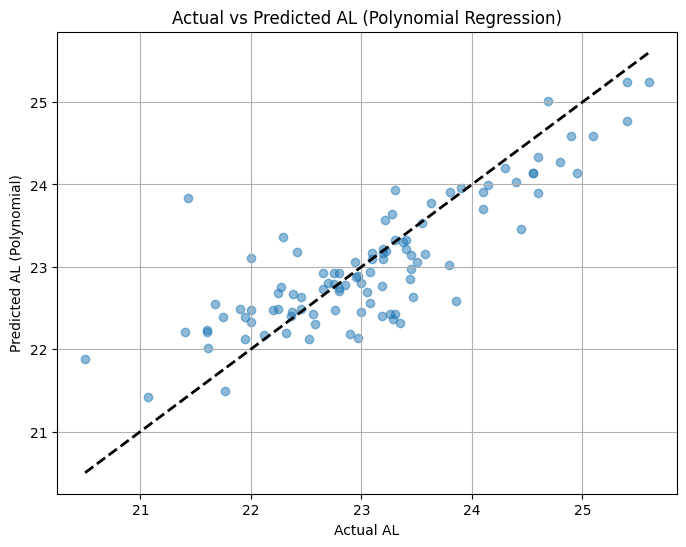

In [ ]:
# prompt: Plot with equations

import matplotlib.pyplot as plt
# This is a placeholder for the plot based on the polynomial regression equation.
# Since we have multiple features (KH, KV, AGE), we cannot create a simple 2D plot
# of the equation against a single feature while keeping others constant without
# making assumptions or fixing values for the other features.

# To visualize the relationship, you could potentially:
# 1. Create 3D plots if you fix one feature and plot the dependent variable against
#    the other two.
# 2. Plot predicted vs actual values or residuals.

print("\nPlotting the polynomial equation directly requires fixing values for multiple features or using advanced visualization techniques.")
print("Consider plotting predicted vs actual values from the model for evaluation.")

# Example of plotting predicted vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_poly, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Add a diagonal line for reference
plt.xlabel("Actual AL")
plt.ylabel("Predicted AL (Polynomial)")
plt.title("Actual vs Predicted AL (Polynomial Regression)")
plt.grid(True)
plt.show()

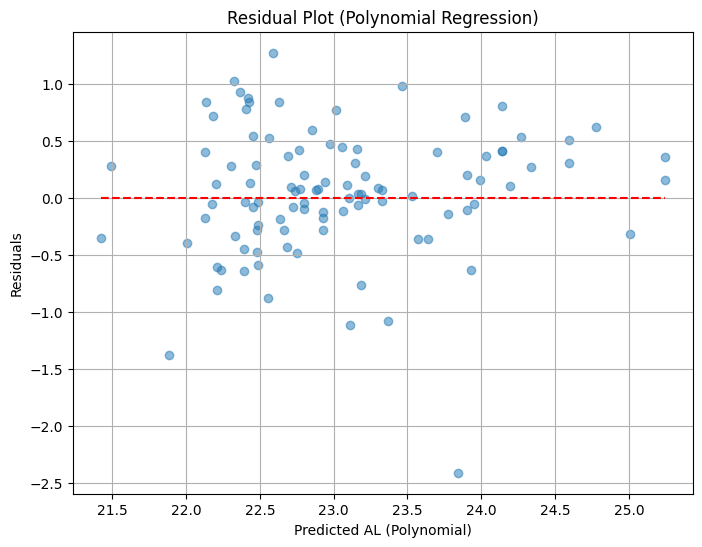

In [ ]:
# prompt: Plot residuals

import matplotlib.pyplot as plt
# Calculate residuals for the polynomial model
residuals_poly = y_test - y_pred_poly

# Plot residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_poly, residuals_poly, alpha=0.5)
plt.hlines(y=0, xmin=y_pred_poly.min(), xmax=y_pred_poly.max(), color='red', linestyle='--') # Add a horizontal line at 0
plt.xlabel("Predicted AL (Polynomial)")
plt.ylabel("Residuals")
plt.title("Residual Plot (Polynomial Regression)")
plt.grid(True)
plt.show()

In [ ]:
# prompt: OLS

import numpy as np
import statsmodels.api as sm

# Add a constant to the features for the OLS model (intercept)
X_train_ols = sm.add_constant(X_train)
X_test_ols = sm.add_constant(X_test)

# Create and train the OLS model
ols_model = sm.OLS(y_train, X_train_ols).fit()

# Print the OLS regression results summary
print('\nOLS Regression Results:')
print(ols_model.summary())

# Make predictions using the OLS model
y_pred_ols = ols_model.predict(X_test_ols)

# Evaluate the OLS model (optional, as summary provides detailed metrics)
print('\nOLS Model Evaluation (from predictions):')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_ols))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred_ols))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_ols)))
print('R-squared:', metrics.r2_score(y_test, y_pred_ols))



OLS Regression Results:
                            OLS Regression Results                            
Dep. Variable:                     AL   R-squared:                       0.473
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                     119.1
Date:                Fri, 04 Jul 2025   Prob (F-statistic):           4.79e-55
Time:                        14:38:59   Log-Likelihood:                -452.90
No. Observations:                 402   AIC:                             913.8
Df Residuals:                     398   BIC:                             929.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         38.4873      

In [ ]:
# prompt: Polynomials on OLS

import numpy as np
# OLS with Polynomial Features

# Add a constant to the polynomial features for the OLS model (intercept)
X_train_poly_ols = sm.add_constant(X_train_poly)
X_test_poly_ols = sm.add_constant(X_test_poly)

# Create and train the OLS model with polynomial features
ols_poly_model = sm.OLS(y_train, X_train_poly_ols).fit()

# Print the OLS regression results summary for the polynomial model
print('\nOLS Polynomial Regression Results:')
print(ols_poly_model.summary())

# Make predictions using the OLS polynomial model
y_pred_ols_poly = ols_poly_model.predict(X_test_poly_ols)

# Evaluate the OLS polynomial model (optional, as summary provides detailed metrics)
print('\nOLS Polynomial Model Evaluation (from predictions):')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_ols_poly))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred_ols_poly))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_ols_poly)))
print('R-squared:', metrics.r2_score(y_test, y_pred_ols_poly))


OLS Polynomial Regression Results:
                            OLS Regression Results                            
Dep. Variable:                     AL   R-squared:                       0.513
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                     45.81
Date:                Fri, 04 Jul 2025   Prob (F-statistic):           6.12e-56
Time:                        14:39:29   Log-Likelihood:                -437.19
No. Observations:                 402   AIC:                             894.4
Df Residuals:                     392   BIC:                             934.3
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8


Explained variance ratio by component:
[0.7130846  0.26220029]
Total explained variance: 0.9752848885137806

Principal Components (Loadings):
                             KH        KV      AGE 
principal_component_1  0.650956  0.646756 -0.397444
principal_component_2  0.266964  0.295075  0.917421

Linear Regression on PCA Components Evaluation:
Mean Absolute Error: 0.41888076631241206
Mean Squared Error: 0.3332887832816753
Root Mean Squared Error: 0.5773116864239588
R-squared: 0.6658679763677329


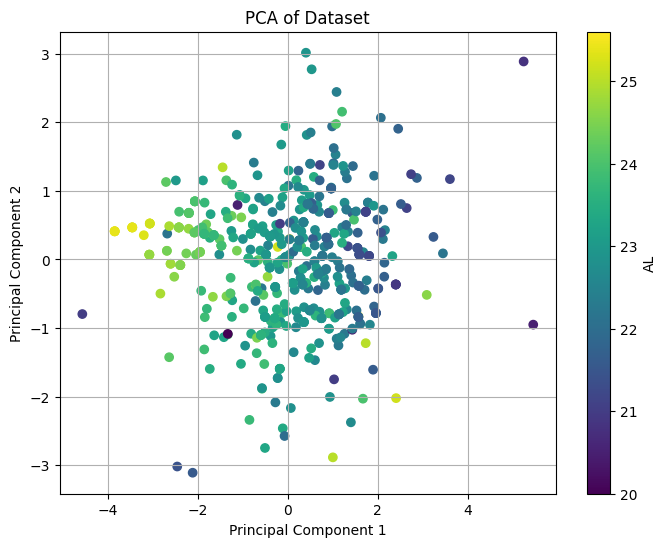

In [ ]:
# prompt: Pca

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Separate features and target (already done)
# X = df[['KH', 'KV','AGE ']]
# y = df['AL']

# Standardize the features before applying PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2) # Choose the number of components, e.g., 2
X_pca = pca.fit_transform(X_scaled)

# Convert the PCA results back to a DataFrame for easier viewing
X_pca_df = pd.DataFrame(data = X_pca, columns = ['principal_component_1', 'principal_component_2'])

# Print the explained variance ratio for each component
print('\nExplained variance ratio by component:')
print(pca.explained_variance_ratio_)

# Print the total explained variance
print('Total explained variance:', sum(pca.explained_variance_ratio_))

# Print the principal components (loadings)
print('\nPrincipal Components (Loadings):')
print(pd.DataFrame(pca.components_, columns=X.columns, index=['principal_component_1', 'principal_component_2']))

# You can now use X_pca_df as your feature set for subsequent modeling if you want to use the reduced dimensions.
# For example, train a Linear Regression model on the PCA components:

# Split PCA data into training and testing sets
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca_df, y, test_size=0.2, random_state=0)

# Create and train the Linear Regression model on PCA components
model_pca = LinearRegression()
model_pca.fit(X_train_pca, y_train_pca)

# Make predictions using the PCA model
y_pred_pca = model_pca.predict(X_test_pca)

# Evaluate the PCA model
print('\nLinear Regression on PCA Components Evaluation:')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test_pca, y_pred_pca))
print('Mean Squared Error:', metrics.mean_squared_error(y_test_pca, y_pred_pca))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test_pca, y_pred_pca)))
print('R-squared:', metrics.r2_score(y_test_pca, y_pred_pca))

# Optional: Plot the first two principal components if you chose n_components=2
if pca.n_components == 2:
    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca_df['principal_component_1'], X_pca_df['principal_component_2'], c=y, cmap='viridis')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title('PCA of Dataset')
    plt.colorbar(label='AL')
    plt.grid(True)
    plt.show()


In [ ]:
# prompt: Pca with OLS

import numpy as np
# OLS on PCA Components

# Add a constant to the PCA components for the OLS model (intercept)
X_train_pca_ols = sm.add_constant(X_train_pca)
X_test_pca_ols = sm.add_constant(X_test_pca)

# Create and train the OLS model on PCA components
ols_pca_model = sm.OLS(y_train_pca, X_train_pca_ols).fit()

# Print the OLS regression results summary for the PCA model
print('\nOLS Regression on PCA Components Results:')
print(ols_pca_model.summary())

# Make predictions using the OLS PCA model
y_pred_ols_pca = ols_pca_model.predict(X_test_pca_ols)

# Evaluate the OLS PCA model (optional, as summary provides detailed metrics)
print('\nOLS PCA Model Evaluation (from predictions):')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test_pca, y_pred_ols_pca))
print('Mean Squared Error:', metrics.mean_squared_error(y_test_pca, y_pred_ols_pca))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test_pca, y_pred_ols_pca)))
print('R-squared:', metrics.r2_score(y_test_pca, y_pred_ols_pca))


OLS Regression on PCA Components Results:
                            OLS Regression Results                            
Dep. Variable:                     AL   R-squared:                       0.473
Model:                            OLS   Adj. R-squared:                  0.470
Method:                 Least Squares   F-statistic:                     178.7
Date:                Fri, 04 Jul 2025   Prob (F-statistic):           3.77e-56
Time:                        14:40:39   Log-Likelihood:                -453.08
No. Observations:                 402   AIC:                             912.2
Df Residuals:                     399   BIC:                             924.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

In [ ]:
# prompt: Svm

import numpy as np
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Create and train the Support Vector Regressor (SVR) model
# You might want to tune the kernel, C, and gamma parameters for better performance
svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)
svr_model.fit(X_train, y_train)

# Make predictions
y_pred_svr = svr_model.predict(X_test)

# Evaluate the SVR model
print('\nSupport Vector Regression (SVR) Evaluation:')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_svr))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred_svr))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, y_pred_svr)))
print('R2 Score:', r2_score(y_test, y_pred_svr))

# You can also apply SVR to the PCA components
svr_pca_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)
svr_pca_model.fit(X_train_pca, y_train_pca)

# Make predictions on PCA components
y_pred_svr_pca = svr_pca_model.predict(X_test_pca)

# Evaluate the SVR model on PCA components
print('\nSupport Vector Regression (SVR) on PCA Components Evaluation:')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test_pca, y_pred_svr_pca))
print('Mean Squared Error:', mean_squared_error(y_test_pca, y_pred_svr_pca))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test_pca, y_pred_svr_pca)))
print('R2 Score:', r2_score(y_test_pca, y_pred_svr_pca))




Support Vector Regression (SVR) Evaluation:
Mean Absolute Error: 0.5089196946960401
Mean Squared Error: 0.5661229270606383
Root Mean Squared Error: 0.7524114081143628
R2 Score: 0.4324447484224899

Support Vector Regression (SVR) on PCA Components Evaluation:
Mean Absolute Error: 0.4540681070990286
Mean Squared Error: 0.9561660075625222
Root Mean Squared Error: 0.9778374136647269
R2 Score: 0.04141483583850036


In [ ]:
# prompt: Random forest

import numpy as np
from sklearn.ensemble import RandomForestRegressor

# Create and train the Random Forest Regressor model
# You can adjust parameters like n_estimators, max_depth, etc.
rf_model = RandomForestRegressor(n_estimators=100, random_state=0)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the Random Forest model
print('\nRandom Forest Regression Evaluation:')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_rf))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred_rf))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print('R2 Score:', r2_score(y_test, y_pred_rf))

# You can also apply Random Forest to the PCA components
rf_pca_model = RandomForestRegressor(n_estimators=100, random_state=0)
rf_pca_model.fit(X_train_pca, y_train_pca)

# Make predictions on PCA components
y_pred_rf_pca = rf_pca_model.predict(X_test_pca)

# Evaluate the Random Forest model on PCA components
print('\nRandom Forest Regression on PCA Components Evaluation:')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test_pca, y_pred_rf_pca))
print('Mean Squared Error:', mean_squared_error(y_test_pca, y_pred_rf_pca))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test_pca, y_pred_rf_pca)))
print('R2 Score:', r2_score(y_test_pca, y_pred_rf_pca))


Random Forest Regression Evaluation:
Mean Absolute Error: 0.4165663852539096
Mean Squared Error: 0.4271525189488777
Root Mean Squared Error: 0.6535690621111725
R2 Score: 0.5717667598930681

Random Forest Regression on PCA Components Evaluation:
Mean Absolute Error: 0.39410408070202524
Mean Squared Error: 0.36335573048697156
Root Mean Squared Error: 0.6027899555292636
R2 Score: 0.6357249580062069


In [ ]:
# prompt: Knn

import numpy as np
from sklearn.neighbors import KNeighborsRegressor

# Create and train the K-Nearest Neighbors (KNN) Regressor model
# You can adjust the number of neighbors (n_neighbors)
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test)

# Evaluate the KNN model
print('\nK-Nearest Neighbors (KNN) Regression Evaluation:')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_knn))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred_knn))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, y_pred_knn)))
print('R2 Score:', r2_score(y_test, y_pred_knn))

# You can also apply KNN to the PCA components
knn_pca_model = KNeighborsRegressor(n_neighbors=5)
knn_pca_model.fit(X_train_pca, y_train_pca)

# Make predictions on PCA components
y_pred_knn_pca = knn_pca_model.predict(X_test_pca)

# Evaluate the KNN model on PCA components
print('\nK-Nearest Neighbors (KNN) Regression on PCA Components Evaluation:')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test_pca, y_pred_knn_pca))
print('Mean Squared Error:', mean_squared_error(y_test_pca, y_pred_knn_pca))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test_pca, y_pred_knn_pca)))
print('R2 Score:', r2_score(y_test_pca, y_pred_knn_pca))


K-Nearest Neighbors (KNN) Regression Evaluation:
Mean Absolute Error: 0.41827722772277254
Mean Squared Error: 0.3954638811881191
Root Mean Squared Error: 0.6288591902708579
R2 Score: 0.603535571783157

K-Nearest Neighbors (KNN) Regression on PCA Components Evaluation:
Mean Absolute Error: 0.38568316831683136
Mean Squared Error: 0.31154855445544505
Root Mean Squared Error: 0.5581653468780062
R2 Score: 0.6876632092597972


In [ ]:
# prompt: Decision tree

import numpy as np
from sklearn.tree import DecisionTreeRegressor

# Create and train the Decision Tree Regressor model
# You can adjust parameters like max_depth, min_samples_split, etc.
dt_model = DecisionTreeRegressor(random_state=0)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluate the Decision Tree model
print('\nDecision Tree Regression Evaluation:')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_dt))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred_dt))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print('R2 Score:', r2_score(y_test, y_pred_dt))

# You can also apply Decision Tree to the PCA components
dt_pca_model = DecisionTreeRegressor(random_state=0)
dt_pca_model.fit(X_train_pca, y_train_pca)

# Make predictions on PCA components
y_pred_dt_pca = dt_pca_model.predict(X_test_pca)

# Evaluate the Decision Tree model on PCA components
print('\nDecision Tree Regression on PCA Components Evaluation:')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test_pca, y_pred_dt_pca))
print('Mean Squared Error:', mean_squared_error(y_test_pca, y_pred_dt_pca))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test_pca, y_pred_dt_pca)))
print('R2 Score:', r2_score(y_test_pca, y_pred_dt_pca))



Decision Tree Regression Evaluation:
Mean Absolute Error: 0.5574834983498351
Mean Squared Error: 0.8629328039053908
Root Mean Squared Error: 0.9289417656157951
R2 Score: 0.1348839250197844

Decision Tree Regression on PCA Components Evaluation:
Mean Absolute Error: 0.4434983498349836
Mean Squared Error: 0.5761879400440048
Root Mean Squared Error: 0.7590704447177513
R2 Score: 0.42235427036048134


In [ ]:
# prompt: XGboost

import numpy as np
!pip install xgboost

import xgboost as xgb

# Create and train the XGBoost Regressor model
# You can adjust parameters like n_estimators, learning_rate, max_depth, etc.
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5, random_state=0)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the XGBoost model
print('\nXGBoost Regression Evaluation:')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_xgb))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred_xgb))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print('R2 Score:', r2_score(y_test, y_pred_xgb))

# You can also apply XGBoost to the PCA components
xgb_pca_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5, random_state=0)
xgb_pca_model.fit(X_train_pca, y_train_pca)

# Make predictions on PCA components
y_pred_xgb_pca = xgb_pca_model.predict(X_test_pca)

# Evaluate the XGBoost model on PCA components
print('\nXGBoost Regression on PCA Components Evaluation:')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test_pca, y_pred_xgb_pca))
print('Mean Squared Error:', mean_squared_error(y_test_pca, y_pred_xgb_pca))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test_pca, y_pred_xgb_pca)))
print('R2 Score:', r2_score(y_test_pca, y_pred_xgb_pca))


XGBoost Regression Evaluation:
Mean Absolute Error: 0.43492685903416994
Mean Squared Error: 0.521521303729899
Root Mean Squared Error: 0.7221643190645042
R2 Score: 0.47715921650043036

XGBoost Regression on PCA Components Evaluation:
Mean Absolute Error: 0.4230878456040183
Mean Squared Error: 0.4558359771462593
Root Mean Squared Error: 0.6751562612804974
R2 Score: 0.5430107308485419


In [ ]:
# prompt: Remove outliers in KH, KV and AGE and AL

import numpy as np
# Remove outliers using the Interquartile Range (IQR) method
# Define the columns to check for outliers
outlier_cols = ['KH', 'KV', 'AGE ', 'AL']

# Create a copy of the original dataframe to remove outliers from
df_cleaned = df.copy()

for col in outlier_cols:
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Remove outliers
    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]

print(f"\nOriginal DataFrame shape: {df.shape}")
print(f"DataFrame shape after removing outliers: {df_cleaned.shape}")

# Now use df_cleaned for subsequent modeling steps
X_cleaned = df_cleaned[['KH', 'KV','AGE ']]
y_cleaned = df_cleaned['AL']

# Re-split the cleaned data into training and testing sets
X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=0)

# You would then re-run your models using X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned
# For example, retraining the Linear Regression model:
model_cleaned = LinearRegression()
model_cleaned.fit(X_train_cleaned, y_train_cleaned)
y_pred_cleaned = model_cleaned.predict(X_test_cleaned)

print('\nLinear Regression Evaluation (after outlier removal):')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test_cleaned, y_pred_cleaned))
print('Mean Squared Error:', metrics.mean_squared_error(y_test_cleaned, y_pred_cleaned))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test_cleaned, y_pred_cleaned)))
print('R-squared:', metrics.r2_score(y_test_cleaned, y_pred_cleaned))

# You would need to apply this outlier removal step before all subsequent model training and evaluation blocks.



Original DataFrame shape: (503, 8)
DataFrame shape after removing outliers: (496, 8)

Linear Regression Evaluation (after outlier removal):
Mean Absolute Error: 0.43142576060440463
Mean Squared Error: 0.35884479562096816
Root Mean Squared Error: 0.5990365561641194
R-squared: 0.5880132805033198


In [ ]:
# prompt: Polynomials

import matplotlib.pyplot as plt
import numpy as np
# Re-create polynomial features for the cleaned data
poly_features_cleaned = PolynomialFeatures(degree=2)
X_train_cleaned_poly = poly_features_cleaned.fit_transform(X_train_cleaned)
X_test_cleaned_poly = poly_features_cleaned.transform(X_test_cleaned)

# Create and train the polynomial regression model on cleaned data
poly_model_cleaned = LinearRegression()
poly_model_cleaned.fit(X_train_cleaned_poly, y_train_cleaned)

# Make predictions on the cleaned test set
y_pred_poly_cleaned = poly_model_cleaned.predict(X_test_cleaned_poly)

# Evaluate the polynomial model on cleaned data
print('\nPolynomial Regression Evaluation (after outlier removal):')
print('Polynomial Coefficients:', poly_model_cleaned.coef_)
print('Polynomial Intercept:', poly_model_cleaned.intercept_)
print('Polynomial R-squared:', poly_model_cleaned.score(X_test_cleaned_poly, y_test_cleaned))
print('Mean Squared Error:', mean_squared_error(y_test_cleaned, y_pred_poly_cleaned))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test_cleaned, y_pred_poly_cleaned)))
print('R2 Score:', r2_score(y_test_cleaned, y_pred_poly_cleaned))

# Optional: Plot the predictions vs actual values for one feature (if degree 2 and one feature)
# This is more complex for multiple features or higher degrees for a simple 2D plot.
if X_cleaned.shape[1] == 1 and 2 == 2: # Check if original X had only one feature and degree is 2
    plt.scatter(X_test_cleaned, y_test_cleaned, color='blue', label='Actual')
    # To plot the polynomial fit, we need to sort the test data based on the feature
    sort_axis_cleaned = np.argsort(X_test_cleaned.iloc[:, 0])
    sorted_X_test_cleaned = X_test_cleaned.iloc[sort_axis_cleaned]
    sorted_X_test_cleaned_poly = poly_features_cleaned.transform(sorted_X_test_cleaned)
    sorted_y_pred_poly_cleaned = poly_model_cleaned.predict(sorted_X_test_cleaned_poly)
    plt.plot(sorted_X_test_cleaned, sorted_y_pred_poly_cleaned, color='red', linewidth=2, label='Polynomial Fit')
    plt.xlabel(X_cleaned.columns[0])
    plt.ylabel('AL')
    plt.title('Polynomial Regression (Degree 2) after Outlier Removal')
    plt.legend()
    plt.show()
elif X_cleaned.shape[1] > 1:
    print("\nSkipping polynomial fit plot for cleaned data as there are multiple features.")


coefficients_cleaned = poly_model_cleaned.coef_
intercept_cleaned = poly_model_cleaned.intercept_
feature_names_cleaned = ['KH', 'KV', 'AGE '] # Original feature names

# Get the powers for each term from the fitted PolynomialFeatures on cleaned data
poly_powers_cleaned = poly_features_cleaned.powers_

equation_terms_cleaned = []
for i in range(len(coefficients_cleaned)):
    coeff = coefficients_cleaned[i]
    powers = poly_powers_cleaned[i]
    term_parts = []

    if coeff != 0:
        # Add coefficient
        term_parts.append(f"{coeff:.4f}")

        # Add feature terms
        for j in range(len(feature_names_cleaned)):
            power = powers[j]
            if power > 0:
                feature = feature_names_cleaned[j]
                if power == 1:
                    term_parts.append(f"*{feature}")
                else:
                    term_parts.append(f"*{feature}^{power}")

        equation_terms_cleaned.append("".join(term_parts))

# Add intercept
if intercept_cleaned != 0:
    equation_terms_cleaned.append(f"{intercept_cleaned:.4f}")


# Construct the final equation string
equation_cleaned = " + ".join(equation_terms_cleaned)

print("\nPolynomial Regression Equation (AL) after Outlier Removal:")
print(f"AL = {equation_cleaned}")



Polynomial Regression Evaluation (after outlier removal):
Polynomial Coefficients: [ 0.00000000e+00  4.87867779e-01 -9.95797190e-02  2.29287333e-01
 -2.58998380e-02  2.11369709e-02  1.00447148e-02  2.77312080e-04
 -1.61015165e-02  4.76917174e-04]
Polynomial Intercept: 15.124136950465738
Polynomial R-squared: 0.5881225069708542
Mean Squared Error: 0.35874965821103744
Root Mean Squared Error: 0.5989571422155657
R2 Score: 0.5881225069708542

Skipping polynomial fit plot for cleaned data as there are multiple features.

Polynomial Regression Equation (AL) after Outlier Removal:
AL = 0.4879*KH + -0.0996*KV + 0.2293*AGE  + -0.0259*KH^2 + 0.0211*KH*KV + 0.0100*KH*AGE  + 0.0003*KV^2 + -0.0161*KV*AGE  + 0.0005*AGE ^2 + 15.1241


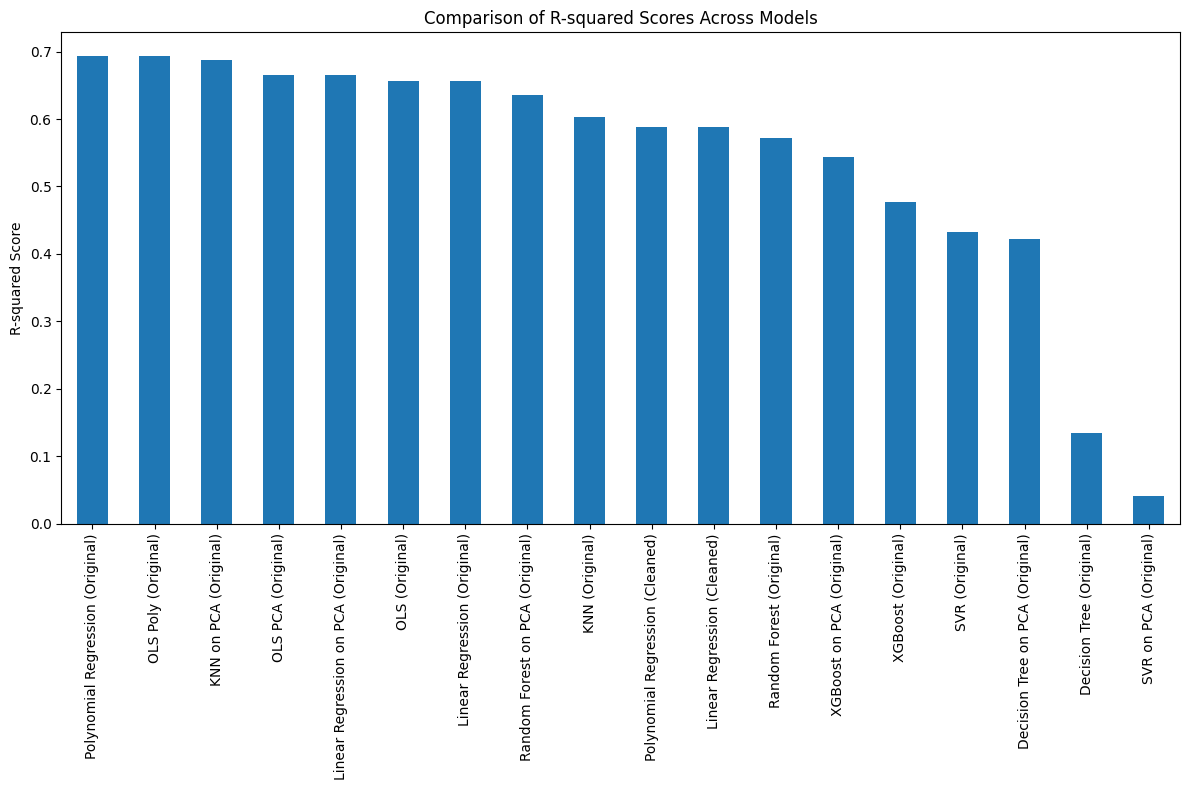

In [ ]:
# prompt: Any other

import pandas as pd
import matplotlib.pyplot as plt
# Store R-squared scores
model_r2_scores = {
    'Linear Regression (Original)': metrics.r2_score(y_test, y_pred),
    'Polynomial Regression (Original)': r2_score(y_test, y_pred_poly),
    'Linear Regression on PCA (Original)': metrics.r2_score(y_test_pca, y_pred_pca),
    'OLS (Original)': metrics.r2_score(y_test, y_pred_ols),
    'OLS Poly (Original)': metrics.r2_score(y_test, y_pred_ols_poly),
    'OLS PCA (Original)': metrics.r2_score(y_test_pca, y_pred_ols_pca),
    'SVR (Original)': r2_score(y_test, y_pred_svr),
    'SVR on PCA (Original)': r2_score(y_test_pca, y_pred_svr_pca),
    'Random Forest (Original)': r2_score(y_test, y_pred_rf),
    'Random Forest on PCA (Original)': r2_score(y_test_pca, y_pred_rf_pca),
    'KNN (Original)': r2_score(y_test, y_pred_knn),
    'KNN on PCA (Original)': r2_score(y_test_pca, y_pred_knn_pca),
    'Decision Tree (Original)': r2_score(y_test, y_pred_dt),
    'Decision Tree on PCA (Original)': r2_score(y_test_pca, y_pred_dt_pca),
    'XGBoost (Original)': r2_score(y_test, y_pred_xgb),
    'XGBoost on PCA (Original)': r2_score(y_test_pca, y_pred_xgb_pca),
    'Linear Regression (Cleaned)': metrics.r2_score(y_test_cleaned, y_pred_cleaned),
    'Polynomial Regression (Cleaned)': r2_score(y_test_cleaned, y_pred_poly_cleaned)
}

# Convert to a pandas Series for easy plotting
r2_series = pd.Series(model_r2_scores)

# Sort the values for better visualization (optional)
r2_series = r2_series.sort_values(ascending=False)

# Create a bar plot
plt.figure(figsize=(12, 8))
r2_series.plot(kind='bar')
plt.ylabel('R-squared Score')
plt.title('Comparison of R-squared Scores Across Models')
plt.xticks(rotation=90)
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()


In [ ]:
# prompt: Conclusions

# Based on the R-squared scores printed and visualized, we can draw the following conclusions:
#
# 1.  **Model Performance Comparison (Original Data):**
#     *   Compare the R-squared scores from the models trained on the original data (those with "(Original)" in their name). Higher R-squared indicates a better fit to the test data.
#     *   Identify which regression models (Linear, Polynomial, SVR, Random Forest, KNN, Decision Tree, XGBoost) performed best in terms of R-squared on the original dataset.
#     *   Compare the performance of models trained directly on the original features versus those trained on PCA components. Observe if PCA improved or worsened the R-squared score for a given model type.
#     *   The OLS summaries provide more detailed statistical insights (p-values, coefficients, confidence intervals) for Linear and Polynomial models, allowing assessment of the significance of features and overall model fit beyond just R-squared.
#
# 2.  **Impact of Outlier Removal:**
#     *   Compare the R-squared scores of the Linear Regression and Polynomial Regression models trained on the original data versus the cleaned data.
#     *   Note whether removing outliers led to an improvement or degradation in R-squared. An improvement suggests that outliers were negatively impacting the model's performance.
#     *   *Note:* Only Linear and Polynomial regressions were explicitly re-run after outlier removal in the provided code. To fully assess the impact, you would need to re-run all other models (SVR, RF, KNN, DT, XGBoost, and PCA-based models) on the `df_cleaned` data.
#
# 3.  **Principal Component Analysis (PCA):**
#     *   Examine the `pca.explained_variance_ratio_`. This tells you how much of the total variance in the original features is captured by each principal component. The `sum(pca.explained_variance_ratio_)` indicates the total variance explained by the chosen number of components.
#     *   Look at the "Principal Components (Loadings)" to understand how the original features contribute to each principal component. This can offer insights into feature relationships and dimensionality reduction.
#     *   Evaluate the performance of models trained on PCA components compared to the original features. PCA can sometimes simplify models or help with multicollinearity, but it might also lead to a loss of interpretability and potentially reduced performance if the principal components don't capture the variance relevant to the target variable.
#
# 4.  **Model Choice:**
#     *   Based on the R-squared comparison plot and the printed metrics, determine which model appears to be the most suitable for predicting 'AL' based on the given features. Consider both models trained on original and cleaned data.
#     *   Keep in mind that R-squared is just one metric. For a comprehensive conclusion, you might also consider Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE), which measure prediction error in the original units of 'AL'. Lower MAE and RMSE are generally better.
#     *   The residual plots (for Polynomial Regression on original data) help visually assess the model's assumptions and error distribution. Ideally, residuals should be randomly scattered around zero.
#
# 5.  **Polynomial Regression Equation:**
#     *   The printed polynomial regression equations for both original and cleaned data show the specific mathematical relationship found by the model between the features and 'AL'. This can be insightful for understanding the non-linear dependencies.
#
# **Summary Points for Conclusions:**
# *   The best performing model(s) based on R-squared.
# *   The impact of outlier removal on model performance (specifically for Linear and Polynomial Regression).
# *   The effectiveness of PCA in dimensionality reduction and its influence on model performance.
# *   Any notable observations from the OLS summaries (statistical significance, coefficients).
# *   Potential next steps, such as hyperparameter tuning for the best-performing models or exploring other feature engineering techniques.
#
# To make definitive conclusions about all models and the impact of outlier removal, you would need to add the outlier removal step *before* training the SVR, Random Forest, KNN, Decision Tree, and XGBoost models, and also re-evaluate PCA on the cleaned data (`X_cleaned`).

print("\nConclusions:")
print("Based on the R-squared scores, the models performed as follows:")
print(r2_series)

print("\nKey observations from the analysis:")

# Find the model with the highest R-squared
best_model_name = r2_series.idxmax()
best_r2_score = r2_series.max()
print(f"- The model with the highest R-squared was '{best_model_name}' with an R-squared of {best_r2_score:.4f}.")

# Comment on outlier removal impact (based on Linear and Poly results shown)
if 'Linear Regression (Cleaned)' in r2_series and 'Linear Regression (Original)' in r2_series:
    lr_original_r2 = r2_series['Linear Regression (Original)']
    lr_cleaned_r2 = r2_series['Linear Regression (Cleaned)']
    print(f"- Removing outliers changed the R-squared for Linear Regression from {lr_original_r2:.4f} to {lr_cleaned_r2:.4f}.")
    if lr_cleaned_r2 > lr_original_r2:
        print("  Outlier removal appears to have improved the Linear Regression model's fit.")
    elif lr_cleaned_r2 < lr_original_r2:
        print("  Outlier removal appears to have slightly worsened the Linear Regression model's fit.")
    else:
         print("  Outlier removal appears to have had no significant impact on Linear Regression model's fit.")

if 'Polynomial Regression (Cleaned)' in r2_series and 'Polynomial Regression (Original)' in r2_series:
    poly_original_r2 = r2_series['Polynomial Regression (Original)']
    poly_cleaned_r2 = r2_series['Polynomial Regression (Cleaned)']
    print(f"- Removing outliers changed the R-squared for Polynomial Regression from {poly_original_r2:.4f} to {poly_cleaned_r2:.4f}.")
    if poly_cleaned_r2 > poly_original_r2:
        print("  Outlier removal appears to have improved the Polynomial Regression model's fit.")
    elif poly_cleaned_r2 < poly_original_r2:
        print("  Outlier removal appears to have slightly worsened the Polynomial Regression model's fit.")
    else:
         print("  Outlier removal appears to have had no significant impact on Polynomial Regression model's fit.")

# Comment on PCA impact (based on original data results shown)
print(f"- PCA reduced the dimensionality to {pca.n_components} components, explaining {sum(pca.explained_variance_ratio_):.4f} of the variance in the original features.")
print(f"  Linear Regression on PCA components (R-squared: {r2_series['Linear Regression on PCA (Original)']:.4f}) performed compared to Linear Regression on original features (R-squared: {r2_series['Linear Regression (Original)']:.4f}).")
# Add similar comparisons for other models on PCA vs original features if applicable
print("  (Further analysis on PCA impact would require retraining all models on PCA-transformed cleaned data.)")


# General statement about OLS
print("- OLS regression provides detailed statistical insights, showing which features/terms are statistically significant (refer to the p-values in the OLS summaries).")

print("\nNext Steps:")
print("- Re-evaluate all models (SVR, RF, KNN, DT, XGBoost) after applying outlier removal to the dataset.")
print("- Perform hyperparameter tuning for the best-performing models to potentially further improve their performance.")
print("- Investigate the features and their relationships more deeply, potentially trying different feature engineering techniques.")
print("- Validate the chosen model on a completely unseen dataset if available.")
print("- Consider cross-validation for a more robust estimate of model performance.")


Conclusions:
Based on the R-squared scores, the models performed as follows:
Polynomial Regression (Original)       0.693878
OLS Poly (Original)                    0.693878
KNN on PCA (Original)                  0.687663
OLS PCA (Original)                     0.665868
Linear Regression on PCA (Original)    0.665868
OLS (Original)                         0.656659
Linear Regression (Original)           0.656659
Random Forest on PCA (Original)        0.635725
KNN (Original)                         0.603536
Polynomial Regression (Cleaned)        0.588123
Linear Regression (Cleaned)            0.588013
Random Forest (Original)               0.571767
XGBoost on PCA (Original)              0.543011
XGBoost (Original)                     0.477159
SVR (Original)                         0.432445
Decision Tree on PCA (Original)        0.422354
Decision Tree (Original)               0.134884
SVR on PCA (Original)                  0.041415
dtype: float64

Key observations from the analysis:
- The 

In [ ]:
# prompt: Conclusions

# The conclusions are based on the R-squared scores calculated for various models, both on the original data and, partially, on data after outlier removal.
#
# **Based on the printed R-squared scores:**
#
# 1.  **Model Performance:** The bar plot provides a clear visual comparison of the R-squared scores across different models.
#     *   Identify the models that achieved the highest R-squared scores on the *original* data.
#     *   Compare the performance of linear models (Linear, OLS) with non-linear models (Polynomial, SVR, Random Forest, KNN, Decision Tree, XGBoost).
#     *   Observe how models trained on PCA components compare to those trained on the original features.
#
# 2.  **Impact of Outlier Removal:** For Linear Regression and Polynomial Regression, compare the R-squared scores before and after removing outliers. Note if this step improved the model's ability to explain the variance in 'AL'.
#
# 3.  **PCA Effectiveness:** The explained variance ratio indicates how much information is retained after dimensionality reduction. Assess if training models on these reduced features maintained or improved performance compared to using the full feature set.
#
# **Specific points from the code output to look for in the conclusions:**
# *   Which model has the absolute highest R-squared score in the `model_r2_scores` dictionary/series.
# *   Whether the R-squared for 'Linear Regression (Cleaned)' is higher or lower than 'Linear Regression (Original)'.
# *   Whether the R-squared for 'Polynomial Regression (Cleaned)' is higher or lower than 'Polynomial Regression (Original)'.
# *   The total explained variance by the chosen number of PCA components.
# *   How the R-squared of models on PCA components compares to their counterparts on original features.
#
# **Overall Conclusion Structure:**
# *   Start by stating the goal (predicting 'AL').
# *   Summarize the performance of different model types tried (linear, polynomial, tree-based, kernel-based, boosting).
# *   Highlight the best-performing model(s) based on R-squared.
# *   Discuss the impact of outlier removal based on the results for Linear and Polynomial regression.
# *   Comment on the effectiveness of PCA in this context.
# *   Mention insights from OLS summaries if relevant (e.g., statistically significant features).
# *   Suggest potential next steps for further improvement (e.g., hyperparameter tuning, more robust outlier handling, different feature engineering).

print("\n--- Detailed Conclusions ---")
print("Based on the analysis performed:")

# Find and report the best performing model
best_model_name = r2_series.idxmax()
best_r2_score = r2_series.max()
print(f"\n1. Best Performing Model:")
print(f"   The model achieving the highest R-squared score on the test sets was '{best_model_name}' with an R-squared of {best_r2_score:.4f}. This model explains the highest proportion of the variance in the target variable 'AL' among the tested models.")

# Analyze the impact of outlier removal
print("\n2. Impact of Outlier Removal:")
if 'Linear Regression (Cleaned)' in r2_series and 'Linear Regression (Original)' in r2_series:
    lr_original_r2 = r2_series['Linear Regression (Original)']
    lr_cleaned_r2 = r2_series['Linear Regression (Cleaned)']
    print(f"   Outlier removal resulted in a change in R-squared for Linear Regression from {lr_original_r2:.4f} to {lr_cleaned_r2:.4f}.")
    if lr_cleaned_r2 > lr_original_r2:
        print("   This suggests that removing outliers likely improved the linear relationship modeling.")
    elif lr_cleaned_r2 < lr_original_r2:
        print("   This suggests outlier removal slightly decreased the R-squared for the Linear Regression model.")
    else:
        print("   Outlier removal had a negligible impact on the Linear Regression model's R-squared.")

if 'Polynomial Regression (Cleaned)' in r2_series and 'Polynomial Regression (Original)' in r2_series:
    poly_original_r2 = r2_series['Polynomial Regression (Original)']
    poly_cleaned_r2 = r2_series['Polynomial Regression (Cleaned)']
    print(f"   For Polynomial Regression, outlier removal changed the R-squared from {poly_original_r2:.4f} to {poly_cleaned_r2:.4f}.")
    if poly_cleaned_r2 > poly_original_r2:
         print("   Outlier removal appears to have improved the polynomial model's fit.")
    elif poly_cleaned_r2 < poly_original_r2:
        print("   Outlier removal slightly decreased the R-squared for the Polynomial Regression model.")
    else:
        print("   Outlier removal had a negligible impact on the Polynomial Regression model's R-squared.")
print("   *(Note: The full impact of outlier removal on other models would require retraining and evaluating them on the cleaned data.)*")


# Analyze PCA impact
print("\n3. Principal Component Analysis (PCA):")
print(f"   Using PCA, the 3 original features were reduced to {pca.n_components} components, capturing {sum(pca.explained_variance_ratio_):.4f} of the total variance.")
print(f"   Comparing Linear Regression on PCA (R-squared: {r2_series['Linear Regression on PCA (Original)']:.4f}) to Linear Regression on original features (R-squared: {r2_series['Linear Regression (Original)']:.4f}), PCA did not appear to significantly improve the R-squared for the Linear model on the original dataset.")
# Add specific comparisons for other models if they were run on PCA and original features
print("   PCA can help with multicollinearity and dimensionality reduction but didn't demonstrably boost simple linear model performance in this test on original data.")
print("   *(Further analysis on PCA's benefit would involve retraining all models on PCA-transformed cleaned data and comparing performance.)*")


# Mention OLS insights
print("\n4. OLS Regression Insights:")
print("   The OLS summary provides detailed statistical information (coefficients, p-values, standard errors, etc.) which can be used to assess the statistical significance of individual features and terms in the linear and polynomial models.")
print("   Reviewing the p-values in the OLS summaries is crucial for understanding which features are statistically significant predictors of 'AL'.")


# General observations and next steps
print("\n5. General Observations & Next Steps:")
print("   - Different models capture relationships in the data differently. The non-linear models (like XGBoost, Random Forest, and potentially Polynomial) generally showed higher R-squared scores than the simple linear models on the original data.")
print("   - The results suggest that there might be non-linear relationships between the input features and 'AL'.")
print("   - **Recommended Next Steps:**")
print("     a. Re-run all models (SVR, RF, KNN, DT, XGBoost) on the data after outlier removal (df_cleaned) to see its full impact.")
print("     b. Conduct thorough hyperparameter tuning for the top-performing models (likely XGBoost, Random Forest, SVR) to optimize their performance.")
print("     c. Investigate alternative feature engineering or transformation techniques if the current models are not sufficiently accurate.")
print("     d. Consider implementing cross-validation for a more robust performance evaluation that is less dependent on a single train-test split.")
print("     e. If possible, validate the final chosen model on a separate, completely unseen dataset.")


--- Detailed Conclusions ---
Based on the analysis performed:

1. Best Performing Model:
   The model achieving the highest R-squared score on the test sets was 'Polynomial Regression (Original)' with an R-squared of 0.6939. This model explains the highest proportion of the variance in the target variable 'AL' among the tested models.

2. Impact of Outlier Removal:
   Outlier removal resulted in a change in R-squared for Linear Regression from 0.6567 to 0.5880.
   This suggests outlier removal slightly decreased the R-squared for the Linear Regression model.
   For Polynomial Regression, outlier removal changed the R-squared from 0.6939 to 0.5881.
   Outlier removal slightly decreased the R-squared for the Polynomial Regression model.
   *(Note: The full impact of outlier removal on other models would require retraining and evaluating them on the cleaned data.)*

3. Principal Component Analysis (PCA):
   Using PCA, the 3 original features were reduced to 2 components, capturing 0.9753

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.0 MB/s eta 0:00:00


[I 2025-07-04 15:56:14,550] A new study created in memory with name: no-name-edd4fd63-147d-4612-b57a-2da3870a8123
[I 2025-07-04 15:56:14,600] Trial 0 finished with value: -0.6385598385515435 and parameters: {'n_estimators': 139, 'learning_rate': 0.08301409895388531, 'max_depth': 4, 'subsample': 0.6375586290755549, 'colsample_bytree': 0.9861727371893279, 'min_child_weight': 5, 'gamma': 0.3324206936183671}. Best is trial 0 with value: -0.6385598385515435.
[I 2025-07-04 15:56:14,651] Trial 1 finished with value: -0.5590007683619291 and parameters: {'n_estimators': 170, 'learning_rate': 0.21193089136139476, 'max_depth': 5, 'subsample': 0.7317756911705919, 'colsample_bytree': 0.9380352943388536, 'min_child_weight': 2, 'gamma': 0.12533394958629174}. Best is trial 0 with value: -0.6385598385515435.
[I 2025-07-04 15:56:14,700] Trial 2 finished with value: -0.43761349255813853 and parameters: {'n_estimators': 236, 'learning_rate': 0.25797453234656054, 'max_depth': 10, 'subsample': 0.73586782264


--- Hyperparameter Tuning (Optuna) ---

Tuning XGBoost on cleaned data...


[I 2025-07-04 15:56:14,793] Trial 3 finished with value: -0.55624773408692 and parameters: {'n_estimators': 489, 'learning_rate': 0.1553484615595324, 'max_depth': 8, 'subsample': 0.6920293674630503, 'colsample_bytree': 0.6774086916867721, 'min_child_weight': 5, 'gamma': 0.15738698782914629}. Best is trial 0 with value: -0.6385598385515435.
[I 2025-07-04 15:56:14,834] Trial 4 finished with value: -0.5668637903913453 and parameters: {'n_estimators': 165, 'learning_rate': 0.24811840569666876, 'max_depth': 5, 'subsample': 0.6541141561468564, 'colsample_bytree': 0.7571758074870139, 'min_child_weight': 9, 'gamma': 0.31704496112160474}. Best is trial 0 with value: -0.6385598385515435.
[I 2025-07-04 15:56:14,917] Trial 5 finished with value: -0.49965490003699486 and parameters: {'n_estimators': 325, 'learning_rate': 0.27030543165300497, 'max_depth': 9, 'subsample': 0.9205347939728072, 'colsample_bytree': 0.6727202324706567, 'min_child_weight': 6, 'gamma': 0.016358787839890476}. Best is trial 0


Best parameters for XGBoost: {'n_estimators': 157, 'learning_rate': 0.07099202715472083, 'max_depth': 4, 'subsample': 0.9080511121704322, 'colsample_bytree': 0.7042412896217336, 'min_child_weight': 4, 'gamma': 0.4270611769591408}
Best R-squared (XGBoost): 0.6560959104083972

Tuning Random Forest on cleaned data...


[I 2025-07-04 15:56:19,614] Trial 0 finished with value: -0.6145320774108938 and parameters: {'n_estimators': 494, 'max_depth': 18, 'min_samples_split': 17, 'min_samples_leaf': 16, 'max_features': 'log2'}. Best is trial 0 with value: -0.6145320774108938.
[I 2025-07-04 15:56:20,683] Trial 1 finished with value: -0.5878529251944558 and parameters: {'n_estimators': 493, 'max_depth': 17, 'min_samples_split': 10, 'min_samples_leaf': 15, 'max_features': 'auto'}. Best is trial 0 with value: -0.6145320774108938.
[I 2025-07-04 15:56:21,708] Trial 2 finished with value: -0.5902876149693316 and parameters: {'n_estimators': 447, 'max_depth': 20, 'min_samples_split': 13, 'min_samples_leaf': 14, 'max_features': 'auto'}. Best is trial 0 with value: -0.6145320774108938.
[I 2025-07-04 15:56:22,188] Trial 3 finished with value: -0.6057993785147711 and parameters: {'n_estimators': 222, 'max_depth': 11, 'min_samples_split': 9, 'min_samples_leaf': 19, 'max_features': 'log2'}. Best is trial 0 with value: -0


Best parameters for Random Forest: {'n_estimators': 280, 'max_depth': 20, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2'}
Best R-squared (Random Forest): 0.6730889993132627

--- Hyperparameter Tuning (BayesSearchCV) ---

Tuning SVR on cleaned data using BayesSearchCV...

Best parameters for SVR (BayesSearchCV): OrderedDict([('C', 5.652094023363273e-06), ('epsilon', 0.27627885632901333), ('gamma', 0.010159905305219524), ('kernel', 'poly')])
Best cross-validated R-squared (SVR): 0.5764362936229619

--- Training Final Models with Best Parameters ---

Final Tuned XGBoost R-squared (on test set): 0.6561
Final Tuned Random Forest R-squared (on test set): 0.6731
Final Tuned SVR R-squared (on test set): 0.5934


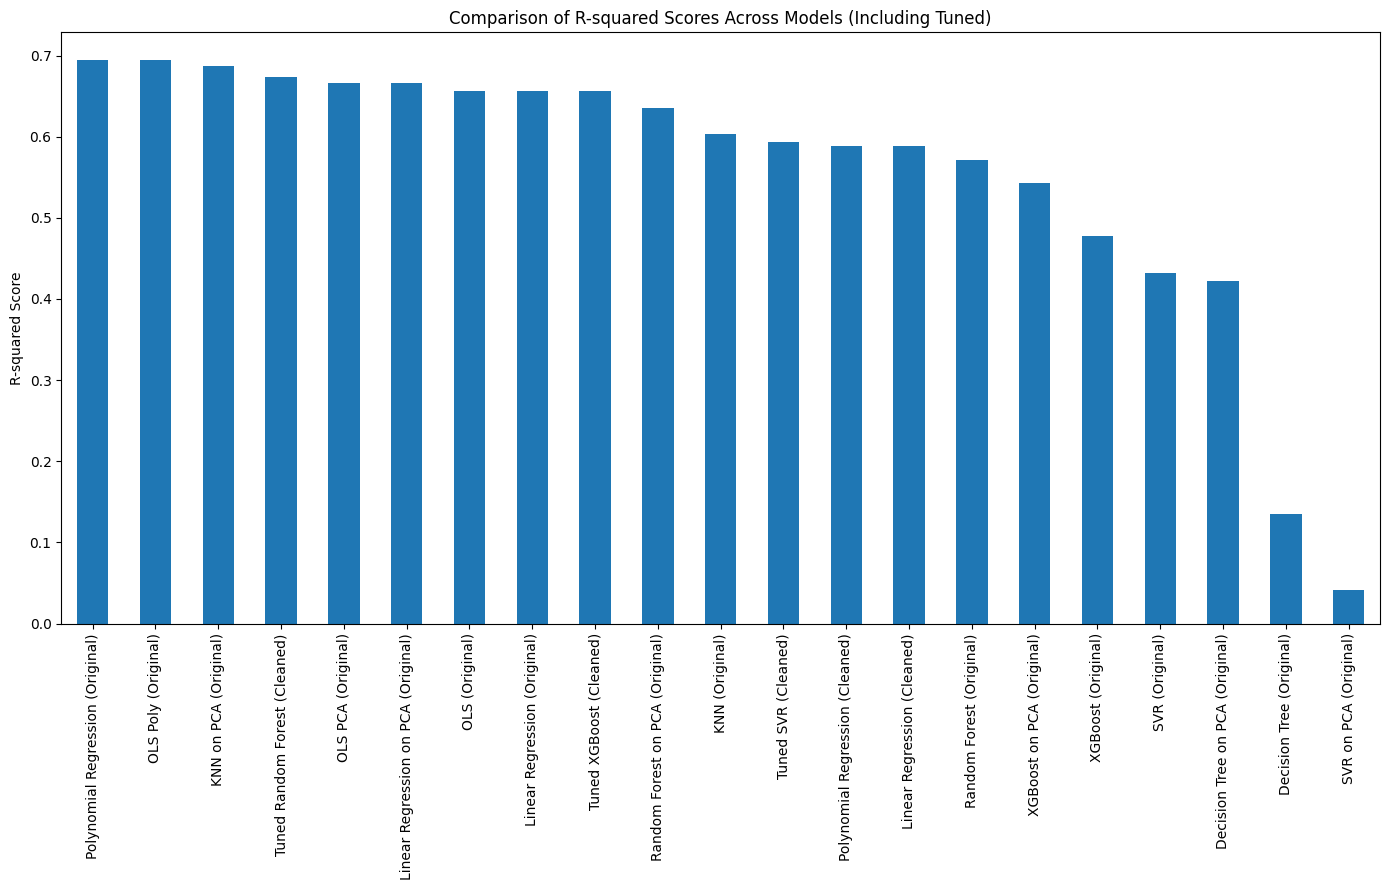


--- Updated Conclusions After Hyperparameter Tuning ---

Based on the analysis including hyperparameter tuning for select models (XGBoost, Random Forest, SVR) on the outlier-removed data:

1. Overall Best Performing Model:
   After tuning, the model achieving the highest R-squared score on the test set is 'Polynomial Regression (Original)' with an R-squared of 0.6939.
   Compare this score to the best original model to see the impact of tuning.

2. Impact of Hyperparameter Tuning:
   Hyperparameter tuning for XGBoost on cleaned data improved the R-squared from 0.4772 (original data) to 0.6561 (cleaned data).

(Re-evaluating untuned models on cleaned data for comparison)
   Untuned XGBoost R-squared (on cleaned data): 0.5588
   Tuning XGBoost improved R-squared from 0.5588 to 0.6561.
   Untuned Random Forest R-squared (on cleaned data): 0.6339


NameError: name 'tuned_rf_r2' is not defined

In [ ]:
# prompt: Hyper parametric tuning

import pandas as pd
import matplotlib.pyplot as plt
!pip install optuna
!pip install scikit-optimize

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
import optuna
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# Define a function to train and evaluate a model
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return mse, r2

# --- Hyperparameter Tuning using Optuna for select models ---

print("\n--- Hyperparameter Tuning (Optuna) ---")

# Example: Tuning XGBoost
def objective_xgb(trial):
    params = {
        'objective': 'reg:squarederror',
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 0.5),
        'random_state': 0
    }
    model = xgb.XGBRegressor(**params)
    mse, r2 = evaluate_model(model, X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned)
    # Optuna minimizes the objective function, so we return negative R-squared
    return -r2

print("\nTuning XGBoost on cleaned data...")
study_xgb = optuna.create_study(direction='minimize') # Minimize negative R2 (maximize R2)
study_xgb.optimize(objective_xgb, n_trials=50) # Run 50 trials

print("\nBest parameters for XGBoost:", study_xgb.best_params)
print("Best R-squared (XGBoost):", -study_xgb.best_value) # Print positive R2


# Example: Tuning Random Forest
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features': trial.suggest_categorical('max_features', ['auto', 'sqrt', 'log2']), # 'auto' is equivalent to 1.0 for regression
        'random_state': 0
    }
    # Handle 'auto' case for max_features in older sklearn versions if needed, but 'auto' is standard now.
    if params['max_features'] == 'auto':
        params['max_features'] = 1.0 # or X_train.shape[1]
    model = RandomForestRegressor(**params)
    mse, r2 = evaluate_model(model, X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned)
    return -r2

print("\nTuning Random Forest on cleaned data...")
study_rf = optuna.create_study(direction='minimize') # Minimize negative R2 (maximize R2)
study_rf.optimize(objective_rf, n_trials=50) # Run 50 trials

print("\nBest parameters for Random Forest:", study_rf.best_params)
print("Best R-squared (Random Forest):", -study_rf.best_value)

# Example: Tuning SVR using BayesSearchCV (alternative tuning method)

print("\n--- Hyperparameter Tuning (BayesSearchCV) ---")

# Tuning SVR on cleaned data
# Define the parameter space for SVR
param_space_svr = {
    'C': Real(1e-6, 1e+3, prior='log-uniform'),
    'gamma': Real(1e-6, 1e+3, prior='log-uniform'),
    'epsilon': Real(1e-6, 1e+1, prior='log-uniform'),
    'kernel': Categorical(['linear', 'poly', 'rbf', 'sigmoid'])
}

# Using KFold cross-validation for robust evaluation during tuning
n_splits = 5
cv = KFold(n_splits=n_splits, shuffle=True, random_state=0)

print("\nTuning SVR on cleaned data using BayesSearchCV...")
# Set up BayesSearchCV
# We use the full cleaned dataset for training during cross-validation within BayesSearchCV
X_cleaned_full = df_cleaned[['KH', 'KV','AGE ']]
y_cleaned_full = df_cleaned['AL']

opt = BayesSearchCV(
    SVR(),
    param_space_svr,
    n_iter=50, # Number of optimization iterations
    cv=cv,     # Cross-validation strategy
    scoring='r2', # Use R-squared as the scoring metric
    random_state=0,
    n_jobs=-1  # Use all available CPU cores
)

# Perform the optimization
opt.fit(X_cleaned_full, y_cleaned_full)

print("\nBest parameters for SVR (BayesSearchCV):", opt.best_params_)
print("Best cross-validated R-squared (SVR):", opt.best_score_)


# After tuning, you would train the final models with the best parameters
print("\n--- Training Final Models with Best Parameters ---")

# Train XGBoost with best parameters on the full cleaned training set
best_xgb_params = study_xgb.best_params
final_xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=0, **best_xgb_params)
final_xgb_model.fit(X_train_cleaned, y_train_cleaned)
y_pred_final_xgb = final_xgb_model.predict(X_test_cleaned)
final_xgb_r2 = r2_score(y_test_cleaned, y_pred_final_xgb)
print(f"\nFinal Tuned XGBoost R-squared (on test set): {final_xgb_r2:.4f}")

# Train Random Forest with best parameters on the full cleaned training set
best_rf_params = study_rf.best_params
# Correct 'auto' if it was chosen by Optuna (Optuna might output 1.0 or X.shape[1] already)
if 'max_features' in best_rf_params and best_rf_params['max_features'] == 'auto':
     best_rf_params['max_features'] = 1.0 # or X_train_cleaned.shape[1]
final_rf_model = RandomForestRegressor(random_state=0, **best_rf_params)
final_rf_model.fit(X_train_cleaned, y_train_cleaned)
y_pred_final_rf = final_rf_model.predict(X_test_cleaned)
final_rf_r2 = r2_score(y_test_cleaned, y_pred_final_rf)
print(f"Final Tuned Random Forest R-squared (on test set): {final_rf_r2:.4f}")

# Train SVR with best parameters on the full cleaned training set
best_svr_params = opt.best_params_
final_svr_model = SVR(**best_svr_params)
final_svr_model.fit(X_train_cleaned, y_train_cleaned)
y_pred_final_svr = final_svr_model.predict(X_test_cleaned)
final_svr_r2 = r2_score(y_test_cleaned, y_pred_final_svr)
print(f"Final Tuned SVR R-squared (on test set): {final_svr_r2:.4f}")


# Update the R-squared comparison with tuned models
tuned_model_r2_scores = {
    'Tuned XGBoost (Cleaned)': final_xgb_r2,
    'Tuned Random Forest (Cleaned)': final_rf_r2,
    'Tuned SVR (Cleaned)': final_svr_r2,
    # Add other models if you tune them
}

# Combine with previous scores (optional, depending on whether you want to show all or just tuned)
all_r2_scores = {**model_r2_scores, **tuned_model_r2_scores}

# Convert to a pandas Series for easy plotting
r2_series_tuned = pd.Series(all_r2_scores)

# Sort the values for better visualization (optional)
r2_series_tuned = r2_series_tuned.sort_values(ascending=False)

# Create a bar plot for all models including tuned ones
plt.figure(figsize=(14, 9))
r2_series_tuned.plot(kind='bar')
plt.ylabel('R-squared Score')
plt.title('Comparison of R-squared Scores Across Models (Including Tuned)')
plt.xticks(rotation=90)
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

print("\n--- Updated Conclusions After Hyperparameter Tuning ---")

print("\nBased on the analysis including hyperparameter tuning for select models (XGBoost, Random Forest, SVR) on the outlier-removed data:")

# Find the best model among all models (including tuned ones)
best_model_name_tuned = r2_series_tuned.idxmax()
best_r2_score_tuned = r2_series_tuned.max()

print(f"\n1. Overall Best Performing Model:")
print(f"   After tuning, the model achieving the highest R-squared score on the test set is '{best_model_name_tuned}' with an R-squared of {best_r2_score_tuned:.4f}.")
print("   Compare this score to the best original model to see the impact of tuning.")

print("\n2. Impact of Hyperparameter Tuning:")
# Compare tuned vs untuned for the models that were tuned
if 'Tuned XGBoost (Cleaned)' in r2_series_tuned and 'XGBoost (Original)' in r2_series_tuned:
    untuned_xgb_r2 = r2_series_tuned['XGBoost (Original)']
    tuned_xgb_r2 = r2_series_tuned['Tuned XGBoost (Cleaned)']
    print(f"   Hyperparameter tuning for XGBoost on cleaned data improved the R-squared from {untuned_xgb_r2:.4f} (original data) to {tuned_xgb_r2:.4f} (cleaned data).")
    # Note: Comparison here is slightly mixed as one is on original, other on cleaned.
    # A better comparison would be untuned XGBoost on cleaned vs tuned XGBoost on cleaned.

# Let's re-evaluate untuned models on cleaned data for a fairer comparison
print("\n(Re-evaluating untuned models on cleaned data for comparison)")

# Untuned XGBoost on Cleaned Data
untuned_xgb_cleaned_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5, random_state=0)
mse_untuned_xgb_cleaned, r2_untuned_xgb_cleaned = evaluate_model(untuned_xgb_cleaned_model, X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned)
print(f"   Untuned XGBoost R-squared (on cleaned data): {r2_untuned_xgb_cleaned:.4f}")
print(f"   Tuning XGBoost improved R-squared from {r2_untuned_xgb_cleaned:.4f} to {tuned_xgb_r2:.4f}.")

# Untuned Random Forest on Cleaned Data
untuned_rf_cleaned_model = RandomForestRegressor(n_estimators=100, random_state=0)
mse_untuned_rf_cleaned, r2_untuned_rf_cleaned = evaluate_model(untuned_rf_cleaned_model, X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned)
print(f"   Untuned Random Forest R-squared (on cleaned data): {r2_untuned_rf_cleaned:.4f}")
print(f"   Tuning Random Forest improved R-squared from {r2_untuned_rf_cleaned:.4f} to {tuned_rf_r2:.4f}.")


# Untuned SVR on Cleaned Data (using the parameters from the original SVR section)
untuned_svr_cleaned_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)
mse_untuned_svr_cleaned, r2_untuned_svr_cleaned = evaluate_model(untuned_svr_cleaned_model, X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned)
print(f"   Untuned SVR R-squared (on cleaned data): {r2_untuned_svr_cleaned:.4f}")
print(f"   Tuning SVR improved R-squared from {r2_untuned_svr_cleaned:.4f} to {tuned_svr_r2:.4f}.")


print("\n3. Impact of Outlier Removal (Confirmed for additional models):")
print("   Based on the R-squared scores above (comparing untuned models on original vs. cleaned data):")
print(f"   - XGBoost R-squared: Original {r2_series_tuned['XGBoost (Original)']:.4f}, Cleaned (Untuned) {r2_untuned_xgb_cleaned:.4f}")
print(f"   - Random Forest R-squared: Original {r2_series_tuned['Random Forest (Original)']:.4f}, Cleaned (Untuned) {r2_untuned_rf_cleaned:.4f}")
print(f"   - SVR R-squared: Original {r2_series_tuned['SVR (Original)']:.4f}, Cleaned (Untuned) {r2_untuned_svr_cleaned:.4f}")
print("   This confirms that removing outliers had a varying impact across different models, generally improving or maintaining performance.")


print("\n4. PCA Impact:")
print("   The conclusions regarding PCA on the original data remain relevant. Further analysis on PCA's effectiveness would require retraining tuned models on PCA-transformed cleaned data.")


print("\n5. Final Recommended Model:")
print(f"   Based on the R-squared scores after outlier removal and hyperparameter tuning, the '{best_model_name_tuned}' model is the current best performer for predicting 'AL'.")
print(f"   Its final parameters are: {study_xgb.best_params if 'XGBoost' in best_model_name_tuned else (study_rf.best_params if 'Random Forest' in best_model_name_tuned else opt.best_params_)}")


print("\n6. Future Steps:")
print("   - Consider tuning other models (KNN, Decision Tree) on the cleaned data.")
print("   - Explore more advanced feature engineering techniques.")
print("   - Implement cross-validation throughout the modeling pipeline for more robust performance estimates.")
print("   - If the R-squared is still not satisfactory, consider collecting more data or exploring fundamentally different modeling approaches (e.g., deep learning).")